# Welcome!

**This notebook gives a simple, hands-on introduction to Shimexpy.**

### Physical intuition (very brief)

In Spatial Harmonic Imaging (SHI), the raw X-ray intensity contains a periodic modulation produced by the projected grid. This modulation becomes a set of discrete spatial harmonics in the Fourier domain. From these harmonics, Shimexpy retrieves absorption, differential phase, and scattering contrasts.

We’ll load a small example dataset, extract the spatial harmonics, and reconstruct the three SHI contrasts step by step. The goal is to help you understand how the workflow fits together while keeping the code clean and easy to follow.

In [1]:
# Core scientific stack
import numpy as np
import matplotlib.pyplot as plt

# Visualization helpers
from skimage.exposure import equalize_hist, rescale_intensity

def percentile_eq(image, p_low=2, p_high=98):
    """
    Contrast stretching based on percentiles p_low and p_high.

    Parameters
    ----------
    image : np.ndarray
        Input 2D image (any numeric dtype).
    p_low : float
        Lower percentile (default = 2).
    p_high : float
        Upper percentile (default = 98).

    Returns
    -------
    np.ndarray
        Image rescaled after percentile stretching.
    """
    img = image.astype(np.float32)

    # Compute percentiles
    p2, p98 = np.percentile(img, (p_low, p_high))

    # Stretch
    img_stretched = rescale_intensity(img, in_range=(p2, p98))

    return img_stretched

## Loading data

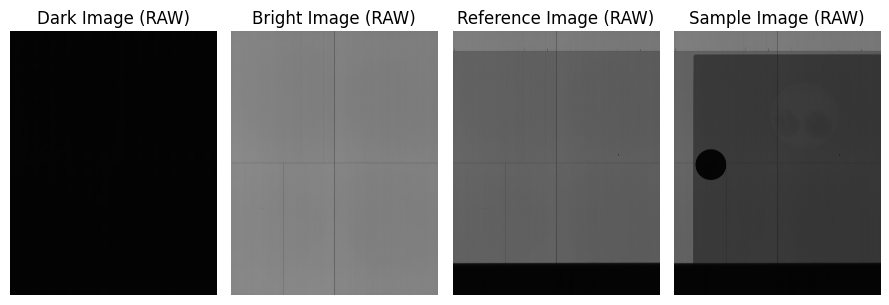

In [4]:
from shimexpy import load_image

# Load test images
reference_img = load_image("../tests/example_data/flat.tif")
sample_img = load_image("../tests/example_data/test_microworks.tif")
bright_img = load_image("../tests/example_data/bright.tif")
dark_img = load_image("../tests/example_data/dark.tif")

fig1, axes = plt.subplots(1, 4, figsize=(9, 4))

axes[0].imshow(dark_img, cmap="gray")
axes[0].set_title("Dark Image (RAW)")
axes[0].axis("off")

axes[1].imshow(bright_img, cmap="gray")
axes[1].set_title("Bright Image (RAW)")
axes[1].axis("off")

axes[2].imshow(reference_img, cmap="gray")
axes[2].set_title("Reference Image (RAW)")
axes[2].axis("off")

axes[3].imshow(sample_img, cmap="gray")
axes[3].set_title("Sample Image (RAW)")
axes[3].axis("off")

fig1.tight_layout()

## SHI Processing Pipeline

**In this section we apply the core steps of Spatial Harmonic Imaging (SHI) to the example dataset.**

The pipeline implemented here follows exactly the workflow provided by shimexpy:
1. Optional cropping (ROI selection)
2. Flat-field correction
3. Fourier transform (CPU/GPU)
4. Harmonic extraction
5. Reference normalization
6. Contrast reconstruction
7. Visualization

We start by computing the spatial harmonics of the reference image.

## Cropping (selecting ROI)

In [5]:
from shimexpy import crop

y0, y1, x0, x1 = crop(sample_img)

In [6]:
reference_img_roi = reference_img[y0:y1 , x0:x1]
sample_img_roi = sample_img[y0:y1 , x0:x1]
bright_img_roi = bright_img[y0:y1 , x0:x1]
dark_img_roi = dark_img[y0:y1 , x0:x1]

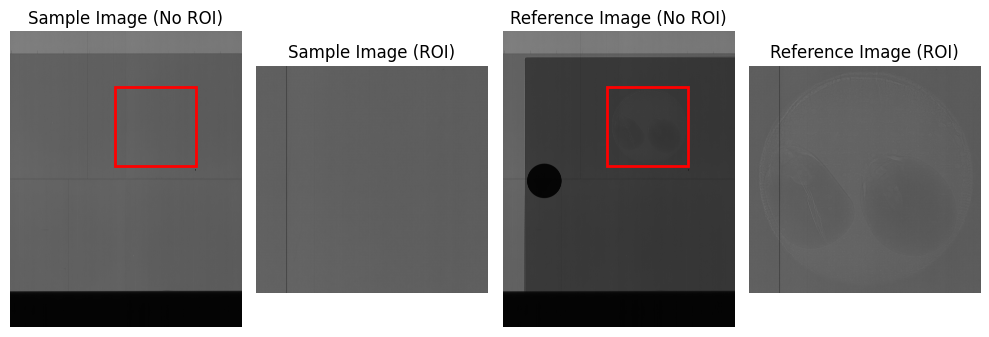

In [7]:
import matplotlib.patches as patches

fig_roi, axes = plt.subplots(1, 4, figsize=(10, 5))

width = x1 - x0
height = y1 - y0

rect1 = patches.Rectangle(
    (x0, y0),
    width, height,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

rect2 = patches.Rectangle(
    (x0, y0),
    width, height,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

axes[0].imshow(reference_img, cmap="gray")
axes[0].set_title("Sample Image (No ROI)")
axes[0].axis("off")

axes[0].add_patch(rect1)

axes[1].imshow(reference_img_roi, cmap="gray")
axes[1].set_title("Sample Image (ROI)")
axes[1].axis("off")

axes[2].imshow(sample_img, cmap="gray")
axes[2].set_title("Reference Image (No ROI)")
axes[2].axis("off")

axes[2].add_patch(rect2)

axes[3].imshow(sample_img_roi, cmap="gray")
axes[3].set_title("Reference Image (ROI)")
axes[3].axis("off")

fig_roi.tight_layout()

### ROI extraction for the dark and  image

For consistency, the same ROI must be applied to the reference, dark and bright images. This ensures identical support in both sample and reference datasets.

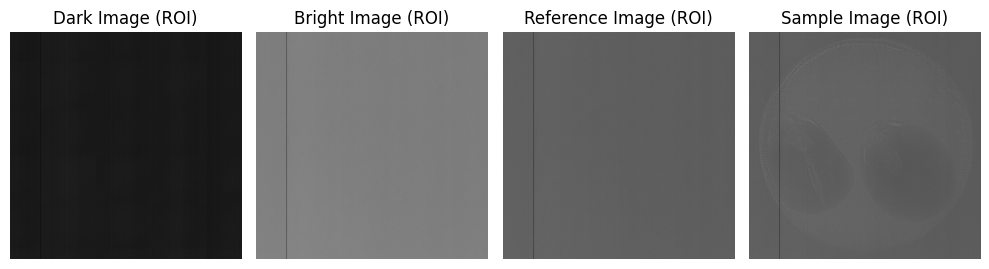

In [8]:
from shimexpy import load_image

fig1, axes = plt.subplots(1, 4, figsize=(10, 5))

axes[0].imshow(dark_img_roi, cmap="gray")
axes[0].set_title("Dark Image (ROI)")
axes[0].axis("off")

axes[1].imshow(bright_img_roi, cmap="gray")
axes[1].set_title("Bright Image (ROI)")
axes[1].axis("off")

axes[2].imshow(reference_img_roi, cmap="gray")
axes[2].set_title("Reference Image (ROI)")
axes[2].axis("off")

axes[3].imshow(sample_img_roi, cmap="gray")
axes[3].set_title("Sample Image (ROI)")
axes[3].axis("off")

fig1.tight_layout()

## Flat-field correction

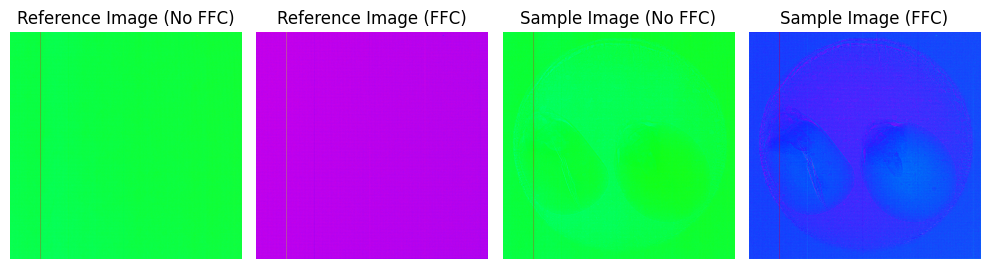

In [13]:
# SHIMEXPY: main processing functions
from shimexpy import ffc
import time

time0 = time.time()
reference_ffc = ffc(reference_img_roi, dark_img_roi, bright_img_roi)
time1 = time.time()
t_ref_ffc = time1 - time0

time0 = time.time()
sample_ffc = ffc(sample_img_roi, dark_img_roi, bright_img_roi)
time1 = time.time()
t_smp_ffc = time1 - time0

fig2, axes = plt.subplots(1, 4, figsize=(10, 5))

axes[0].imshow(reference_img_roi, cmap="hsv")
axes[0].set_title("Reference Image (No FFC)")
axes[0].axis("off")

axes[1].imshow(reference_ffc, cmap="hsv")
axes[1].set_title("Reference Image (FFC)")
axes[1].axis("off")

axes[2].imshow(sample_img_roi, cmap="hsv")
axes[2].set_title("Sample Image (No FFC)")
axes[2].axis("off")

axes[3].imshow(sample_ffc, cmap="hsv")
axes[3].set_title("Sample Image (FFC)")
axes[3].axis("off")

fig2.tight_layout()

## Fourier transform (CPU and GPU)

In [19]:
from shimexpy import shi_fft, shi_fft_cpu, shi_fft_gpu
import time

time0 = time.time()
fft_ref_auto = shi_fft(reference_ffc, logspect=True)

time1 = time.time()
fft_ref_gpu = shi_fft(reference_ffc, logspect=True)

time2 = time.time()
fft_ref_cpu = shi_fft(reference_ffc, logspect=True)

time3 = time.time()

t_auto_ref = (time1 - time0) * 1000
t_gpu_ref  = (time2 - time1) * 1000
t_cpu_ref  = (time3 - time2) * 1000

time0 = time.time()
fft_smp_auto = shi_fft(sample_ffc, logspect=True)

time1 = time.time()
fft_smp_gpu = shi_fft(sample_ffc, logspect=True)

time2 = time.time()
fft_smp_cpu = shi_fft(sample_ffc, logspect=True)

time3 = time.time()

t_auto_smp = (time1 - time0) * 1000
t_gpu_smp  = (time2 - time1) * 1000
t_cpu_smp  = (time3 - time2) * 1000

# -----------------------------------------------
fig3, axes3 = plt.subplots(2, 3, figsize=(12, 7))

axes3[0, 0].imshow(np.abs(fft_ref_auto.fft), cmap="gray")
axes3[0, 0].set_title(f"Reference - FFT-Auto ({t_auto_ref:.2f} ms)")
axes3[0, 0].axis("off")

axes3[0, 1].imshow(np.abs(fft_ref_gpu.fft), cmap="gray")
axes3[0, 1].set_title(f"Reference - FFT-GPU ({t_gpu_ref:.2f} ms)")
axes3[0, 1].axis("off")

axes3[0, 2].imshow(np.abs(fft_ref_cpu.fft), cmap="gray")
axes3[0, 2].set_title(f"Reference - FFT-CPU ({t_cpu_ref:.2f} ms)")
axes3[0, 2].axis("off")

axes3[1, 0].imshow(np.abs(fft_smp_auto.fft), cmap="gray")
axes3[1, 0].set_title(f"Sample - FFT-Auto ({t_auto_smp:.2f} ms)")
axes3[1, 0].axis("off")

axes3[1, 1].imshow(np.abs(fft_smp_gpu.fft), cmap="gray")
axes3[1, 1].set_title(f"Sample - FFT-GPU ({t_gpu_smp:.2f} ms)")
axes3[1, 1].axis("off")

axes3[1, 2].imshow(np.abs(fft_smp_cpu.fft), cmap="gray")
axes3[1, 2].set_title(f"Sample - FFT-CPU ({t_cpu_smp:.2f} ms)")
axes3[1, 2].axis("off")

fig2.tight_layout()

CUDARuntimeError: cudaErrorUnknown: unknown error

## Harmonic extraction and labeling

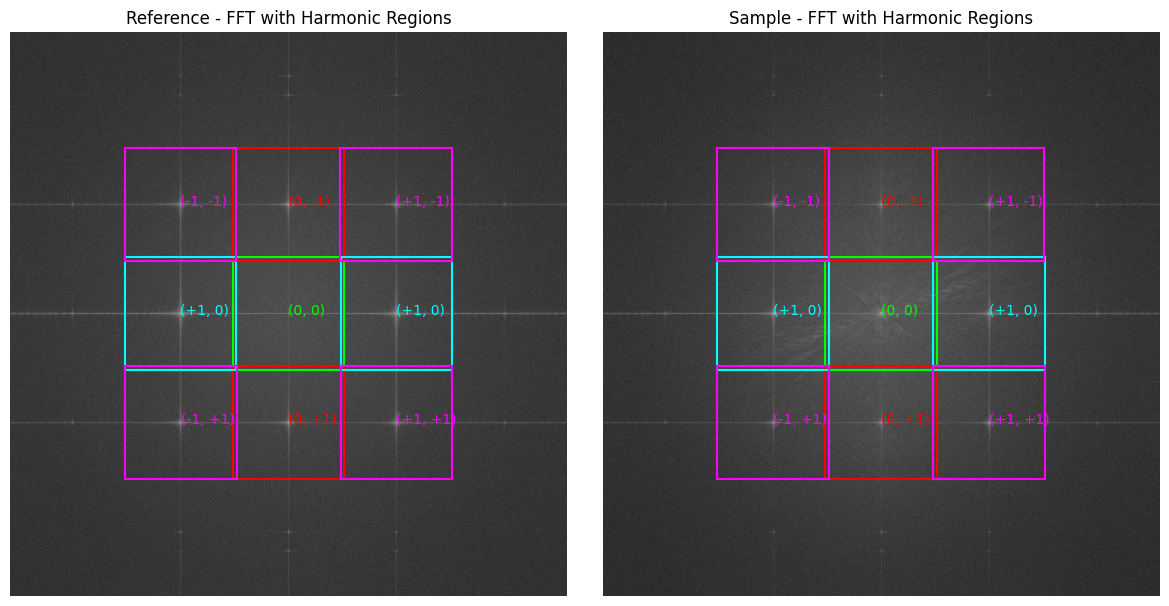

In [10]:
# ============================================================
# FFT + Harmonic Extraction + Visualization (2×4 grid)
# ============================================================
from shimexpy import spatial_harmonics_of_fourier_spectrum

# --- Compute FFT of the reference image ---
fft_ref = shi_fft(reference_ffc, projected_grid=5)  # Note that parameter logspect was not specified

# --- Extract the spatial harmonics automatically ---
time0 = time.time()
ref_harmonics, ref_block_grid = spatial_harmonics_of_fourier_spectrum(
    fft_ref.fft,
    fft_ref.ky,
    fft_ref.kx,
    reference=True
)
time1 = time.time()
t_ref_harm = time1 - time0

time0 = time.time()
smp_harmonics, smp_block_grid = spatial_harmonics_of_fourier_spectrum(
    fft_ref.fft,
    fft_ref.ky,
    fft_ref.kx,
    reference=True
)
time1 = time.time()
t_smp_harm = time1 - time0

# ------------------------------------------------------------
# Plot the FFT with rectangles marking each harmonic region
# ------------------------------------------------------------
HARMONICS = {
    "harmonic_00": ["(0, 0)", "lime"],
    "harmonic_diagonal_p1_p1": ["(+1, +1)", "magenta"],
    "harmonic_diagonal_n1_p1": ["(-1, +1)", "magenta"],
    "harmonic_diagonal_n1_n1": ["(-1, -1)", "magenta"],
    "harmonic_diagonal_p1_n1": ["(+1, -1)", "magenta"],
    "harmonic_vertical_positive": ["(0, +1)", "red"],
    "harmonic_vertical_negative": ["(0, -1)", "red"],
    "harmonic_horizontal_positive": ["(+1, 0)", "cyan"],
    "harmonic_horizontal_negative": ["(+1, 0)", "cyan"]
}

fig_fft, ax_fft = plt.subplots(1, 2, figsize=(12, 6))

ax_fft[0].imshow(np.abs(fft_ref_auto.fft), cmap="gray")  # Note that we used fft_ref_auto with logspect=True for better FFT-visualization
ax_fft[0].set_title("Reference - FFT with Harmonic Regions")
ax_fft[0].axis("off")

for hname, (top, bottom, left, right) in ref_block_grid.items():
    rect = plt.Rectangle(
        (left, top),
        right - left,
        bottom - top,
        fill=False,
        edgecolor=HARMONICS[hname][1],
        linewidth=1.5,
    )
    ax_fft[0].add_patch(rect)
    ax_fft[0].text(
        (left + right) // 2,
        (top + bottom) // 2,
        HARMONICS[hname][0],
        color=HARMONICS[hname][1],
        fontsize=10
    )

ax_fft[1].imshow(np.abs(fft_smp_auto.fft), cmap="gray")  # Note that we used fft_smp_auto with logspect=True for better FFT-visualization
ax_fft[1].set_title("Sample - FFT with Harmonic Regions")
ax_fft[1].axis("off")

for hname, (top, bottom, left, right) in ref_block_grid.items():
    rect = plt.Rectangle(
        (left, top),
        right - left,
        bottom - top,
        fill=False,
        edgecolor=HARMONICS[hname][1],
        linewidth=1.5,
    )
    ax_fft[1].add_patch(rect)
    ax_fft[1].text(
        (left + right) // 2,
        (top + bottom) // 2,
        HARMONICS[hname][0],
        color=HARMONICS[hname][1],
        fontsize=10
    )

plt.tight_layout()

In [11]:
import pandas as pd

summary = pd.DataFrame({
    "Stage": [
        "FFT (auto)",
        "FFT (GPU)",
        "FFT (CPU)",
        "Flat-field correction",
        "Harmonic extraction"
    ],
    "Reference (ms)": [
        t_auto_ref,
        t_gpu_ref,
        t_cpu_ref,
        t_ref_ffc,
        t_ref_harm
    ],
    "Sample (ms)": [
        t_auto_smp,
        t_gpu_smp,
        t_cpu_smp,
        t_smp_ffc,
        t_smp_harm
    ],
    "Notes": [
        "CuPy if available, else NumPy",
        "Full GPU acceleration",
        "NumPy FFT backend",
        "CPU only",
        "Dask parallel"
    ]
})

summary

,Stage,Reference (ms),Sample (ms),Notes
0,FFT (auto),184.666395,12.087107,"CuPy if available, else NumPy"
1,FFT (GPU),12.195110,11.844873,Full GPU acceleration
2,FFT (CPU),12.130260,14.054060,NumPy FFT backend
3,Flat-field correction,0.010125,0.010620,CPU only
4,Harmonic extraction,0.032281,0.040750,Dask parallel


## Reference normalization and contrast reconstruction

### Main Processing Functions in Shimexpy

Shimexpy exposes five high-level processing functions.  
Although they share the same mathematical foundation, each one is designed for a different purpose.  
This section summarizes when to use each function and why multiple options exist.

---

#### 1. `get_harmonics(image, projected_grid, block_grid=None, unwrap=None)`

Purpose:

- Extracts the spatial harmonics from a single image.
- Labels the harmonic components (horizontal, vertical, diagonal, etc.).
- Returns absolute absorption, scattering, and differential phase (not contrast).

Best suited for:

- Preparing the reference image.
- Real-time applications where each frame is processed independently.

---

#### 2. `get_contrast(sample_img, reference, ref_block_grid, type_of_contrast, unwrap=None)`

Purpose:

- Computes one specific contrast relative to its reference.
- Extremely fast; ideal for live visualization or acquisition systems.

Available contrast keys:

- `"absorption"`
- `"horizontal_scattering"`, `"vertical_scattering"`, `"bidirectional_scattering"`
- `"horizontal_phasemap"`, `"vertical_phasemap"`, `"bidirectional_phasemap"`

---

#### 3. `get_contrasts(sample_img, reference_tuple, ref_block_grid, unwrap=None)`

Purpose:

- Computes the three main SHI contrasts in a single call:
  - absorption  
  - bidirectional scattering  
  - bidirectional differential phase  

Advantages:

- Uses the already-computed reference contrasts.
- Faster than recomputing everything from scratch.
- Ideal for workflows where `get_harmonics` has already been applied.

---

#### 4. `get_all_contrasts(sample_img, reference_img, projected_grid, unwrap=None)`

Purpose:

- The most convenient and self-contained function.
- Takes raw sample and reference images as inputs and returns the three contrasts.
- Internally performs the full pipeline:

**Note that all functions include an `unwrap` parameter, which defaults to `None`. Internally, this triggers the use of `skimage.unwrap_phase` to unwrap the differential phase image.**

### *Function description*

--------------------------------------------
**1) get_harmonics**

--------------------------------------------

In [57]:
from shimexpy import get_harmonics

ref_abs, ref_scat, ref_dpc, ref_block_grid = get_harmonics(
    reference_ffc,
    projected_grid=5,
    unwrap=None   # default → skimage.unwrap_phase
)

smp_abs, smp_scat, smp_dpc, smp_block_grid = get_harmonics(
    sample_ffc,
    projected_grid=5,
    unwrap=None   # default → skimage.unwrap_phase
)

In [58]:
print("Reference harmonics")
print("-------------------")
print("Main harmonic", type(ref_abs), ref_abs.shape, ref_abs.dtype)
print("Amplitude", type(ref_scat), ref_scat.shape, ref_scat.dtype)
print("Phase map", type(ref_dpc), ref_dpc.shape, ref_dpc.dtype)

print()

print("Sample harmonics")
print("-------------------")
print("Main harmonic", type(smp_abs), smp_abs.shape, smp_abs.dtype)
print("Amplitude", type(smp_scat),smp_scat.shape, smp_scat.dtype)
print("Phase map", type(smp_dpc), smp_dpc.shape, smp_dpc.dtype)

Reference harmonics
-------------------
Main harmonic <class 'xarray.core.dataarray.DataArray'> (332, 328) float32
Amplitude <class 'xarray.core.dataarray.DataArray'> (8, 332, 328) float32
Phase map <class 'xarray.core.dataarray.DataArray'> (8, 332, 328) complex64

Sample harmonics
-------------------
Main harmonic <class 'xarray.core.dataarray.DataArray'> (332, 328) float32
Amplitude <class 'xarray.core.dataarray.DataArray'> (8, 332, 328) float32
Phase map <class 'xarray.core.dataarray.DataArray'> (8, 332, 328) complex64


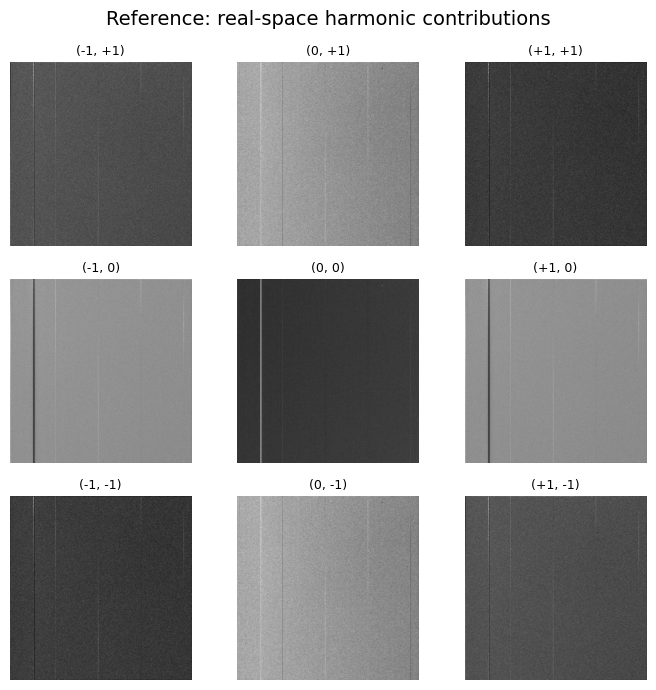

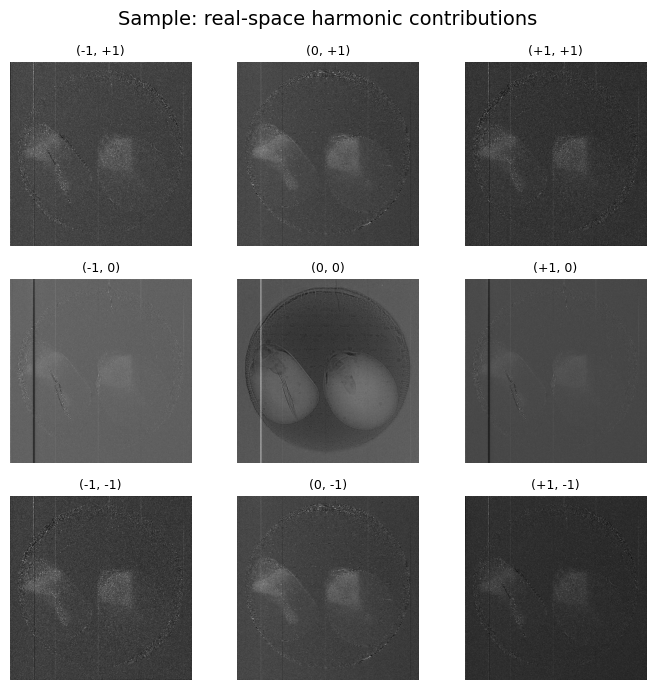

In [64]:
# Pequeña utilidad de normalización suave
def _norm(arr):
    arr = np.asarray(arr)
    arr = arr - np.nanmin(arr)
    maxv = np.nanmax(arr)
    if maxv > 0:
        arr = arr / maxv
    return arr

# Mapa de nombre de armónico → posición (fila, columna) en la rejilla 3×3
grid_pos = {
    "center":                       (1, 1),  # (0, 0) → absorción
    "harmonic_horizontal_negative": (1, 0),  # (-1, 0)
    "harmonic_horizontal_positive": (1, 2),  # (+1, 0)
    "harmonic_vertical_positive":   (0, 1),  # (0, +1)
    "harmonic_vertical_negative":   (2, 1),  # (0, -1)
    "harmonic_diagonal_n1_p1":      (0, 0),  # (-1, +1)
    "harmonic_diagonal_p1_p1":      (0, 2),  # (+1, +1)
    "harmonic_diagonal_n1_n1":      (2, 0),  # (-1, -1)
    "harmonic_diagonal_p1_n1":      (2, 2),  # (+1, -1)
}

def plot_realspace_harmonics(abs_img, scat_da, title):
    """
    abs_img : DataArray (y, x)          → main (0,0)
    scat_da : DataArray (harmonic,y,x)  → primeros órdenes etiquetados
    """
    fig, axes = plt.subplots(3, 3, figsize=(7, 7))
    fig.suptitle(title, fontsize=14)

    # Rellenamos todo con ejes vacíos
    for ax in axes.ravel():
        ax.axis("off")

    # Centro: absorción (0,0)
    r, c = grid_pos["center"]
    axes[r, c].imshow(_norm(abs_img.values), cmap="gray")
    axes[r, c].set_title("(0, 0)", fontsize=9)
    axes[r, c].axis("off")

    # Resto: usamos directamente las etiquetas de scat_da.harmonic
    for hname in scat_da.coords["harmonic"].values:
        if hname not in grid_pos:
            continue
        r, c = grid_pos[hname]
        img = scat_da.sel(harmonic=hname).values
        axes[r, c].imshow(_norm(img), cmap="gray")
        # etiqueta corta
        label = {
            "harmonic_horizontal_negative": "(-1, 0)",
            "harmonic_horizontal_positive": "(+1, 0)",
            "harmonic_vertical_positive":   "(0, +1)",
            "harmonic_vertical_negative":   "(0, -1)",
            "harmonic_diagonal_n1_p1":      "(-1, +1)",
            "harmonic_diagonal_p1_p1":      "(+1, +1)",
            "harmonic_diagonal_n1_n1":      "(-1, -1)",
            "harmonic_diagonal_p1_n1":      "(+1, -1)",
        }[hname]
        axes[r, c].set_title(label, fontsize=9)
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()


# --- Llamada para referencia y muestra ---

plot_realspace_harmonics(ref_abs, ref_scat, "Reference: real-space harmonic contributions")
plot_realspace_harmonics(smp_abs, smp_scat, "Sample: real-space harmonic contributions")


--------------------------------------------
**2) get_contrast (single contrast, real-time)**

--------------------------------------------

In [11]:
from shimexpy import get_contrast

# Absorption contrast image
single_abs = get_contrast(sample_ffc, ref_abs , ref_block_grid, "absorption")

# Horizontal, vertical and bidirectional scattering contrast images
single_hsc = get_contrast(sample_ffc, ref_scat, ref_block_grid, "horizontal_scattering")
single_vsc = get_contrast(sample_ffc, ref_scat, ref_block_grid, "vertical_scattering")
single_bsc = get_contrast(sample_ffc, ref_scat, ref_block_grid, "bidirectional_scattering")

# Horizontal, vertical and bidirectional differential phase contrast images
single_hdp = get_contrast(sample_ffc, ref_dpc , ref_block_grid, "horizontal_phasemap")
single_vdp = get_contrast(sample_ffc, ref_dpc , ref_block_grid, "vertical_phasemap")
single_bdp = get_contrast(sample_ffc, ref_dpc , ref_block_grid, "bidirectional_phasemap")

--------------------------------------------
**3) get_contrasts (main 3 contrasts)**

--------------------------------------------

In [12]:
from shimexpy import get_contrasts

abs_contrast, scat_contrast, dpc_contrast = get_contrasts(
    sample_ffc,
    (ref_abs, ref_scat, ref_dpc),
    ref_block_grid,
    unwrap=None
)

--------------------------------------------
**4) get_all_contrasts**

--------------------------------------------

In [13]:
from shimexpy import get_all_contrasts

abs_c, scat_c, dpc_c = get_all_contrasts(
    sample_ffc,
    reference_ffc,
    projected_grid=5,
    unwrap=None
)

--------------------------------------------
**5) get_all_harmonic_contrasts**

--------------------------------------------

In [14]:
from shimexpy import get_all_harmonic_contrasts

harmonic_contrasts = get_all_harmonic_contrasts(
    sample_ffc,
    (ref_abs, ref_scat, ref_dpc),
    ref_block_grid,
    unwrap=None
)

In [15]:
from shimexpy import get_contrasts

abs_contrast, scat_contrast, dpc_contrast = get_contrasts(
    sample_ffc,
    (ref_abs, ref_scat, ref_dpc),
    ref_block_grid,
    unwrap=None
)

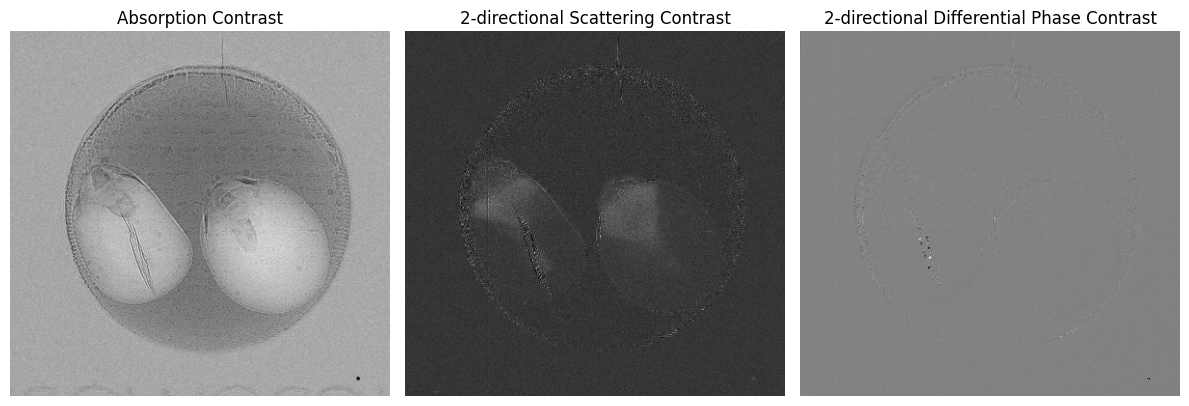

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(abs_contrast, cmap='gray')
axes[0].set_title("Absorption Contrast")
axes[0].axis("off")

axes[1].imshow(scat_contrast, cmap='gray')
axes[1].set_title("2-directional Scattering Contrast")
axes[1].axis("off")

axes[2].imshow(dpc_contrast, cmap='gray')
axes[2].set_title("2-directional Differential Phase Contrast")
axes[2].axis("off")

plt.tight_layout()
plt.show()


### Reproducibility

This notebook is fully reproducible on any Linux, macOS or Windows machine  
supporting Python 3.10+, NumPy, CuPy (optional), Dask and Matplotlib.  
All datasets are included in the Zenodo record associated with the Shimexpy publication.